In [3]:
from pathlib import Path

# ==========================================
# Experiment Paths
# ==========================================

EXPERIMENT_DIR = Path("../experiments/E03_HyperparameterOptimization")

FIGURES_DIR = EXPERIMENT_DIR / "figures"
MODELS_DIR = EXPERIMENT_DIR / "trained_models"
CM_DIR = EXPERIMENT_DIR / "confusion_matrices"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
import pandas as pd
import numpy as np
import joblib
import json
import time

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [5]:
data_path = "../data/cicids2017_cleaned.csv"

chunks = pd.read_csv(
    data_path,
    chunksize=100000
)

chunk = next(chunks)

print(chunk.shape)

print(chunk["Attack Type"].value_counts())

(100000, 53)
Attack Type
Normal Traffic    84992
Port Scanning     15008
Name: count, dtype: int64


In [6]:
# ==========================================
# Balanced Sampling (Reproducible)
# ==========================================

normal_data = []
attack_data = []

chunks = pd.read_csv(
    data_path,
    chunksize=100000
)

chunk_id = 0

for chunk in chunks:

    chunk_id += 1

    chunk.columns = chunk.columns.str.strip()


    normal = chunk[
        chunk["Attack Type"] == "Normal Traffic"
    ]


    attack = chunk[
        chunk["Attack Type"] != "Normal Traffic"
    ]


    # --------------------------------------
    # Sample Normal Traffic
    # --------------------------------------

    if len(normal) > 0:

        normal_data.append(

            normal.sample(

                n=min(len(normal),500),

                random_state=42 + chunk_id

            )

        )


    # --------------------------------------
    # Sample Attack Traffic
    # --------------------------------------

    if len(attack) > 0:

        attack_data.append(

            attack.sample(

                n=min(len(attack),500),

                random_state=142 + chunk_id

            )

        )


    if (
        len(normal_data)*500 >= 50000
        and
        len(attack_data)*500 >= 50000
    ):

        break



df_normal = pd.concat(normal_data)

df_attack = pd.concat(attack_data)



df_final = pd.concat(

    [
        df_normal,
        df_attack
    ]

)



# Final shuffle

df_final = df_final.sample(

    frac=1,

    random_state=42

).reset_index(drop=True)



print(df_final.shape)

print(df_final["Attack Type"].value_counts())

(21812, 53)
Attack Type
Normal Traffic    13000
DoS                3006
Brute Force        2492
Port Scanning      1313
DDoS               1000
Bots                806
Web Attacks         195
Name: count, dtype: int64


In [7]:
le = LabelEncoder()

df_final["Attack Type Encoded"] = le.fit_transform(

    df_final["Attack Type"]

)

print(

    dict(

        zip(

            le.classes_,

            le.transform(le.classes_)

        )

    )

)

{'Bots': np.int64(0), 'Brute Force': np.int64(1), 'DDoS': np.int64(2), 'DoS': np.int64(3), 'Normal Traffic': np.int64(4), 'Port Scanning': np.int64(5), 'Web Attacks': np.int64(6)}


In [8]:
joblib.dump(

    le,

    EXPERIMENT_DIR / "label_encoder.pkl"

)

['..\\experiments\\E03_HyperparameterOptimization\\label_encoder.pkl']

In [9]:
X = df_final.drop(

    [

        "Attack Type",

        "Attack Type Encoded"

    ],

    axis=1

)

y = df_final["Attack Type Encoded"]

print(X.shape)

(21812, 52)


In [10]:
joblib.dump(

    list(X.columns),

    EXPERIMENT_DIR / "feature_names.pkl"

)

['..\\experiments\\E03_HyperparameterOptimization\\feature_names.pkl']

In [11]:
X_train_full, X_test_full, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.30,

    stratify=y,

    random_state=42

)

print(X_train_full.shape)

print(X_test_full.shape)

(15268, 52)
(6544, 52)


In [12]:
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(

    X_train_full,

    y_train

)

importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

importance_df.head(20)

,Feature,Importance
0,Destination Port,0.121626
11,Bwd Packet Length Std,0.055553
8,Bwd Packet Length Max,0.037988
29,Bwd Header Length,0.037531
42,Init_Win_bytes_forward,0.032920
1,Flow Duration,0.031921
10,Bwd Packet Length Mean,0.031678
3,Total Length of Fwd Packets,0.029839
36,Packet Length Variance,0.027416
41,Subflow Fwd Bytes,0.026902


In [13]:
importance_df.to_csv(

    EXPERIMENT_DIR /

    "feature_importance.csv",

    index=False

)

In [14]:
feature_sets = {

    "All Features":

        list(X.columns),

    "Top 30":

        importance_df["Feature"].head(30).tolist(),

    "Top 25":

        importance_df["Feature"].head(25).tolist(),

    "Top 20":

        importance_df["Feature"].head(20).tolist(),

    "Top 15":

        importance_df["Feature"].head(15).tolist()

}

for name,features in feature_sets.items():

    print(name,len(features))

All Features 52
Top 30 30
Top 25 25
Top 20 20
Top 15 15


In [15]:
selected_features = pd.DataFrame({

    "Top30":

        pd.Series(

            feature_sets["Top 30"]

        ),

    "Top25":

        pd.Series(

            feature_sets["Top 25"]

        ),

    "Top20":

        pd.Series(

            feature_sets["Top 20"]

        ),

    "Top15":

        pd.Series(

            feature_sets["Top 15"]

        )

})

selected_features.to_csv(

    EXPERIMENT_DIR /

    "selected_features.csv",

    index=False

)

In [16]:
selected_features = feature_sets["Top 30"]

X_train = X_train_full[selected_features]

X_test = X_test_full[selected_features]

print(X_train.shape)

print(X_test.shape)

(15268, 30)
(6544, 30)


الان سوف نبدأ ب Stage 2

In [17]:
# ==========================================
# Baseline XGBoost Model
# ==========================================

baseline_model = XGBClassifier(

    eval_metric="mlogloss",

    random_state=42

)

start_train = time.time()

baseline_model.fit(

    X_train,

    y_train

)

baseline_training_time = time.time() - start_train

In [18]:
# ==========================================
# Prediction
# ==========================================

start_pred = time.time()

y_pred = baseline_model.predict(

    X_test

)

baseline_prediction_time = time.time() - start_pred

In [19]:
# ==========================================
# Evaluation
# ==========================================

baseline_accuracy = accuracy_score(

    y_test,

    y_pred

)

baseline_precision = precision_score(

    y_test,

    y_pred,

    average="weighted"

)

baseline_recall = recall_score(

    y_test,

    y_pred,

    average="weighted"

)

baseline_f1 = f1_score(

    y_test,

    y_pred,

    average="weighted"

)

In [20]:
# ==========================================
# Display Results
# ==========================================

baseline_results = pd.DataFrame({

    "Model":[

        "Baseline XGBoost"

    ],

    "Accuracy":[

        baseline_accuracy

    ],

    "Precision":[

        baseline_precision

    ],

    "Recall":[

        baseline_recall

    ],

    "F1-score":[

        baseline_f1

    ],

    "Training Time (s)":[

        baseline_training_time

    ],

    "Prediction Time (s)":[

        baseline_prediction_time

    ]

})

baseline_results

,Model,Accuracy,Precision,Recall,F1-score,Training Time (s),Prediction Time (s)
0,Baseline XGBoost,0.997555,0.997556,0.997555,0.997553,1.951913,0.052363


In [21]:
# ==========================================
# Save Baseline Model
# ==========================================
joblib.dump(

    baseline_model,

    MODELS_DIR /

    "baseline_xgboost.pkl"

)

['..\\experiments\\E03_HyperparameterOptimization\\trained_models\\baseline_xgboost.pkl']

In [22]:
# ==========================================
# Save Baseline Results
# ==========================================
baseline_results.to_csv(

    EXPERIMENT_DIR /

    "baseline_results.csv",

    index=False

)

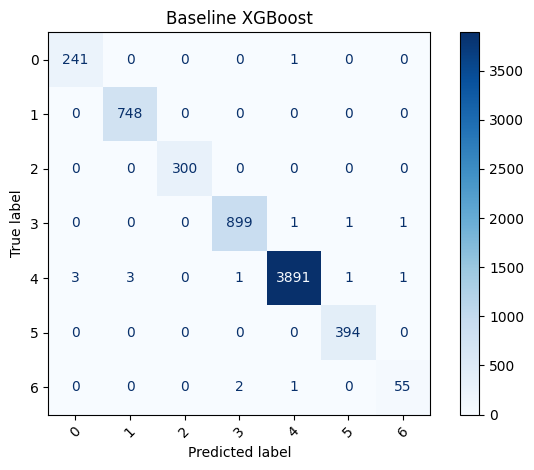

In [23]:
# ==========================================
# Baseline Confusion Matrix
# ==========================================

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred,

    cmap="Blues",

    xticks_rotation=45

)

plt.title(

    "Baseline XGBoost"

)

plt.tight_layout()

plt.savefig(

    CM_DIR /

    "baseline_xgboost_cm.png",

    dpi=300

)

plt.show()

In [24]:
# ==========================================
# Baseline Performance Summary
# ==========================================

print("="*50)

print("Baseline XGBoost")

print("="*50)

print(f"Accuracy          : {baseline_accuracy:.6f}")

print(f"Precision         : {baseline_precision:.6f}")

print(f"Recall            : {baseline_recall:.6f}")

print(f"F1-score          : {baseline_f1:.6f}")

print(f"Training Time     : {baseline_training_time:.4f} sec")

print(f"Prediction Time   : {baseline_prediction_time:.4f} sec")

Baseline XGBoost
Accuracy          : 0.997555
Precision         : 0.997556
Recall            : 0.997555
F1-score          : 0.997553
Training Time     : 1.9519 sec
Prediction Time   : 0.0524 sec


In [25]:
from sklearn.model_selection import RandomizedSearchCV

In [26]:
# ==========================================
# Hyperparameter Search Space
# ==========================================

param_grid = {

    "n_estimators": [100, 200, 300],

    "max_depth": [3, 5, 7, 9],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "subsample": [0.8, 0.9, 1.0],

    "colsample_bytree": [0.8, 0.9, 1.0],

    "gamma": [0, 0.1, 0.3],

    "min_child_weight": [1, 3, 5]

}

In [27]:
# ==========================================
# Random Search            إنشاء RandomizedSearchCV
# ==========================================

random_search = RandomizedSearchCV(

    estimator=XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    ),

    param_distributions=param_grid,

    n_iter=50,

    cv=5,

    scoring="f1_weighted",

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [28]:
# ==========================================
# Hyperparameter Search
# ==========================================

start_search = time.time()

random_search.fit(

    X_train,

    y_train

)

search_time = time.time() - start_search

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [29]:
print("="*60)

print("Best Parameters")

print("="*60)

print(random_search.best_params_)

print()

print("Best Cross Validation Score")

print(random_search.best_score_)

Best Parameters
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 1.0}

Best Cross Validation Score
0.9978981980201388


In [30]:
best_params = random_search.best_params_

with open(

    EXPERIMENT_DIR /

    "best_parameters.json",

    "w"

) as f:

    json.dump(

        best_params,

        f,

        indent=4

    )

In [31]:
best_model = random_search.best_estimator_

In [32]:
joblib.dump(

    best_model,

    MODELS_DIR /

    "optimized_xgboost.pkl"

)

['..\\experiments\\E03_HyperparameterOptimization\\trained_models\\optimized_xgboost.pkl']

In [33]:
#زمن البحث   الخلية 31

print("="*50)

print("Hyperparameter Search Finished")

print("="*50)

print(f"Search Time : {search_time:.2f} seconds")

Hyperparameter Search Finished
Search Time : 357.97 seconds


In [34]:
# ==========================================
# Train Optimized Model on Same Split
# ==========================================

optimized_model = XGBClassifier(

    **random_search.best_params_,

    eval_metric="mlogloss",

    random_state=42

)


start_train = time.time()


optimized_model.fit(

    X_train,

    y_train

)


optimized_training_time = time.time() - start_train

In [35]:
# ==========================================
# Optimized Prediction
# ==========================================


start_pred = time.time()


y_pred_opt = optimized_model.predict(

    X_test

)


optimized_prediction_time = time.time() - start_pred

In [36]:
# ==========================================
# Optimized Metrics
# ==========================================


optimized_accuracy = accuracy_score(

    y_test,

    y_pred_opt

)


optimized_precision = precision_score(

    y_test,

    y_pred_opt,

    average="weighted"

)


optimized_recall = recall_score(

    y_test,

    y_pred_opt,

    average="weighted"

)


optimized_f1 = f1_score(

    y_test,

    y_pred_opt,

    average="weighted"

)

In [37]:
comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (s)",
        "Prediction Time (s)"

    ],


    "Baseline":[

        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_training_time,
        baseline_prediction_time

    ],


    "Optimized":[

        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1,
        optimized_training_time,
        optimized_prediction_time

    ]

})


comparison["Improvement (%)"] = (

    (comparison["Optimized"] -
     comparison["Baseline"])

    /

    comparison["Baseline"]

) * 100



comparison

,Metric,Baseline,Optimized,Improvement (%)
0,Accuracy,0.997555,0.998166,0.061275
1,Precision,0.997556,0.998163,0.060813
2,Recall,0.997555,0.998166,0.061275
3,F1-score,0.997553,0.998161,0.060989
4,Training Time (s),1.951913,2.955698,51.425665
5,Prediction Time (s),0.052363,0.058209,11.165851


In [38]:
comparison.to_csv(

    EXPERIMENT_DIR /

    "comparison_results.csv",

    index=False

)

In [39]:
# ==========================================
# Save Optimized Model
# ==========================================

joblib.dump(

    best_model,

    MODELS_DIR /

    "optimized_xgboost.pkl"

)

print("Optimized model saved successfully.")

Optimized model saved successfully.


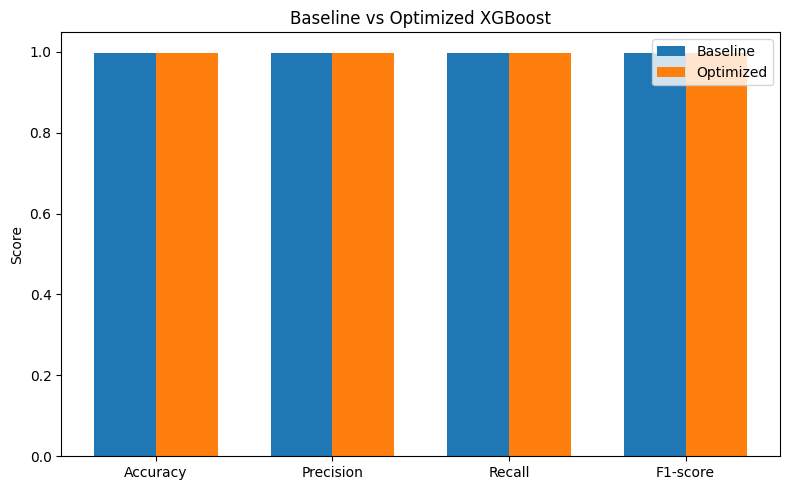

In [40]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

baseline = [
    baseline_accuracy,
    baseline_precision,
    baseline_recall,
    baseline_f1
]

optimized = [
   optimized_accuracy,
   optimized_precision,
   optimized_recall,
   optimized_f1,
       
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    [i - width/2 for i in x],
    baseline,
    width=width,
    label="Baseline"
)

plt.bar(
    [i + width/2 for i in x],
    optimized,
    width=width,
    label="Optimized"
)

plt.xticks(x, metrics)

plt.ylabel("Score")

plt.title("Baseline vs Optimized XGBoost")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "comparison_before_after.png",
    dpi=300
)

plt.show()

In [41]:
# ==========================================
# Optimized Model Prediction
# ==========================================

start_pred = time.time()

y_pred_best = best_model.predict(
    X_test
)

best_prediction_time = time.time() - start_pred

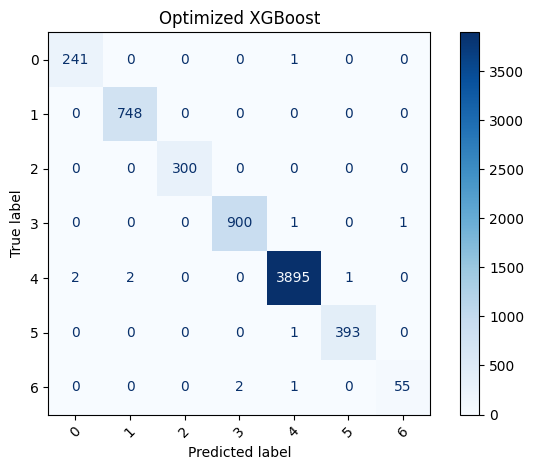

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred_best,

    cmap="Blues",

    xticks_rotation=45

)

plt.title("Optimized XGBoost")

plt.tight_layout()

plt.savefig(

    CM_DIR /

    "optimized_xgboost_cm.png",

    dpi=300

)

plt.show()

In [43]:
joblib.dump(
    best_model,
    MODELS_DIR / "optimized_xgboost.pkl"
)

['..\\experiments\\E03_HyperparameterOptimization\\trained_models\\optimized_xgboost.pkl']

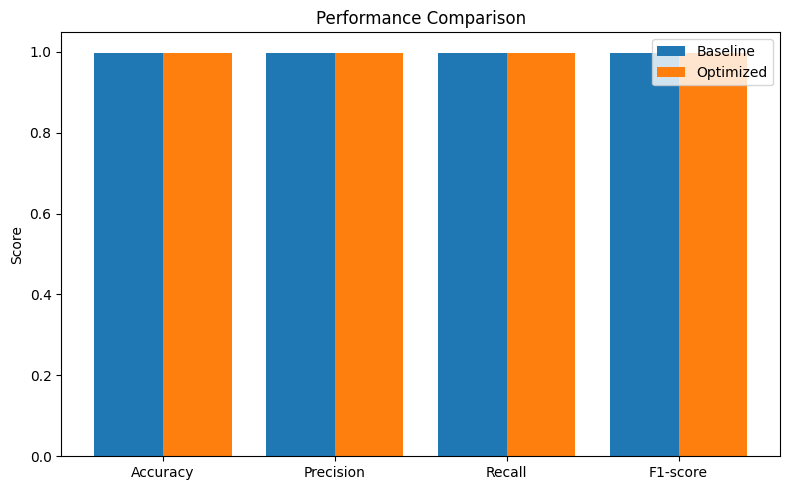

In [44]:
import matplotlib.pyplot as plt

performance = comparison.iloc[:4]

plt.figure(figsize=(8,5))

x = range(len(performance))

plt.bar(
    [i-0.2 for i in x],
    performance["Baseline"],
    width=0.4,
    label="Baseline"
)

plt.bar(
    [i+0.2 for i in x],
    performance["Optimized"],
    width=0.4,
    label="Optimized"
)

plt.xticks(
    x,
    performance["Metric"]
)

plt.ylabel("Score")

plt.title("Performance Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "performance_comparison.png",
    dpi=300
)

plt.show()

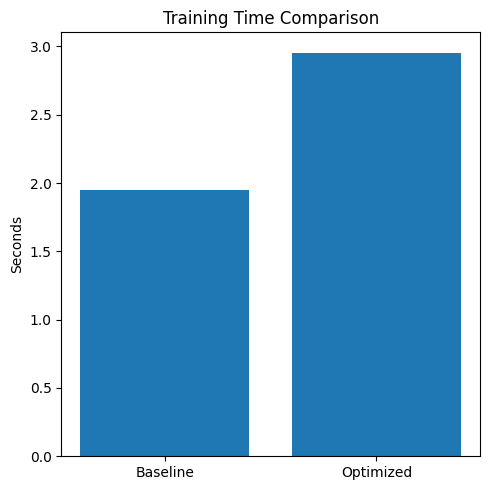

In [45]:
import matplotlib.pyplot as plt

training = comparison[
    comparison["Metric"]=="Training Time (s)"
]

plt.figure(figsize=(5,5))

plt.bar(
    ["Baseline","Optimized"],
    training.iloc[0][["Baseline","Optimized"]]
)

plt.ylabel("Seconds")

plt.title("Training Time Comparison")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "training_time_comparison.png",
    dpi=300
)

plt.show()

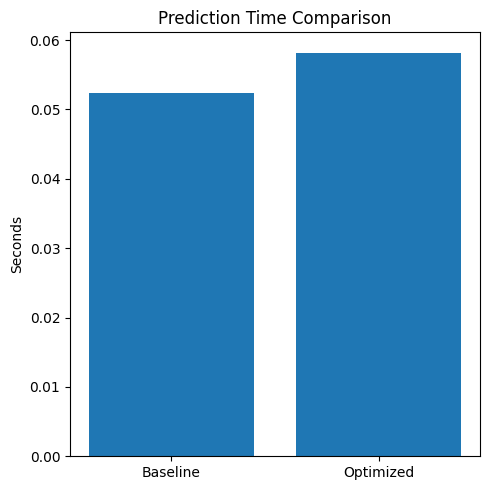

In [46]:
import matplotlib.pyplot as plt

prediction = comparison[
    comparison["Metric"]=="Prediction Time (s)"
]

plt.figure(figsize=(5,5))

plt.bar(
    ["Baseline","Optimized"],
    prediction.iloc[0][["Baseline","Optimized"]]
)

plt.ylabel("Seconds")

plt.title("Prediction Time Comparison")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "prediction_time_comparison.png",
    dpi=300
)

plt.show()

(0.995, 1.0)

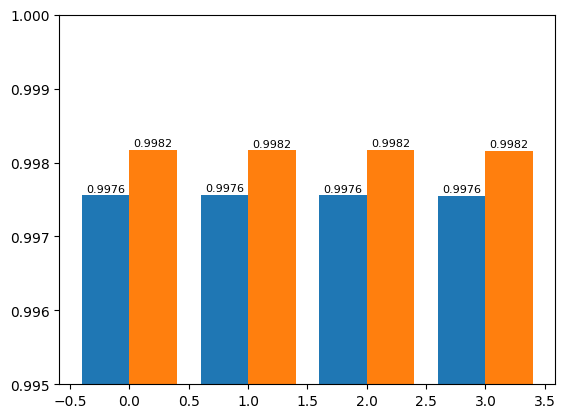

In [47]:
bars1 = plt.bar(
    [i-0.2 for i in x],
    performance["Baseline"],
    width=0.4,
    label="Baseline"
)

bars2 = plt.bar(
    [i+0.2 for i in x],
    performance["Optimized"],
    width=0.4,
    label="Optimized"
)

for bar in list(bars1)+list(bars2):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.00005,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=8
    )

plt.ylim(0.995,1.0)

In [48]:
print(type(X_train))
print(X_train.shape)
print(EXPERIMENT_DIR)

<class 'pandas.core.frame.DataFrame'>
(15268, 30)
..\experiments\E03_HyperparameterOptimization


In [49]:
import joblib

joblib.dump(
    list(X_train.columns),
    EXPERIMENT_DIR / "feature_names.pkl"
)

print("feature_names.pkl saved successfully.")

feature_names.pkl saved successfully.
